# EJERCCIO DECISION TREE

In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


## CARGA DATOS

In [9]:
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True, as_frame=True)

type(X), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [10]:
X.shape, y.shape

((178, 13), (178,))

In [11]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [12]:
X.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

In [13]:
y.unique()

array([0, 1, 2])

In [14]:
y.value_counts()

,count
target,
1,71
0,59
2,48


## PARTICIÓN TRAIN TEST

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (142, 13)
X_test shape: (36, 13)
y_train shape: (142,)
y_test shape: (36,)


In [16]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=3, random_state=42)


clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [17]:
clf.score(X_train, y_train)

0.9929577464788732

In [18]:
clf.score(X_test, y_test)

0.9444444444444444

In [19]:
from sklearn.metrics import confusion_matrix

y_pred = clf.predict(X_test)

confusion_matrix(y_test, y_pred)

array([[11,  1,  0],
       [ 0, 14,  0],
       [ 0,  1,  9]])

In [20]:
load_wine().target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

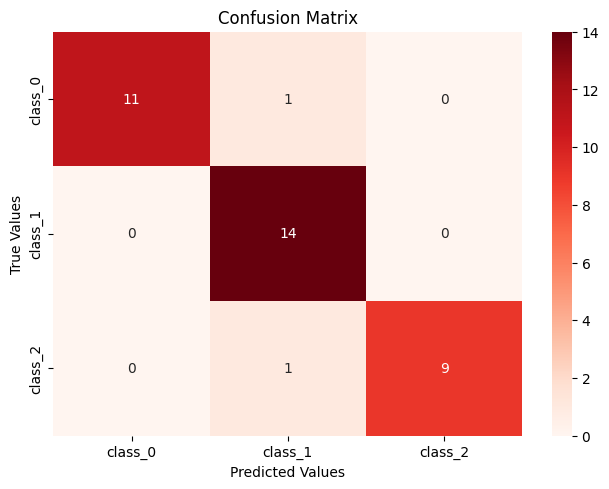

In [26]:
mat_conf = confusion_matrix(y_test, y_pred)

# crear dataframe auxiliar
dataframe = pd.DataFrame(mat_conf, index=['class_0', 'class_1','class_2'], columns=['class_0', 'class_1','class_2'])

# crear heatmap
sns.heatmap(dataframe, annot=True, cbar=True, cmap='Reds')
plt.title('Confusion Matrix')

plt.tight_layout(), plt.xlabel('Predicted Values'), plt.ylabel('True Values');